___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright Pierian Data</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>
# RNN Example for Time Series

**TASK: IMPORT THE BASIC LIBRARIES YOU THINK YOU WILL USE**

In [1]:
# IMPORTS HERE
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

import seaborn as sns
sns.set_style("darkgrid")

import warnings
warnings.filterwarnings("ignore")

%config InlineBackened.figure_format ="svg"

In [2]:
import tensorflow

## Data

Info about this data set: https://fred.stlouisfed.org/series/TRFVOLUSM227NFWA

Read in the data set "Miles_Traveled.csv" from the Data folder. Figure out how to set the date to a datetime index columns

In [6]:
df = pd.read_csv(r"..//Data//Miles_Traveled.csv" ,  index_col=["DATE"], parse_dates=True)
df.index.freq = "MS"
df

,TRFVOLUSM227NFWA
DATE,
1970-01-01,80173.0
1970-02-01,77442.0
1970-03-01,90223.0
1970-04-01,89956.0
1970-05-01,97972.0
...,...
2018-08-01,286608.0
2018-09-01,260595.0
2018-10-01,282174.0


**Task: Change the column names to Value**

In [7]:
# CODE HERE
df.columns = ["Value"]
df.head()

,Value
DATE,
1970-01-01,80173.0
1970-02-01,77442.0
1970-03-01,90223.0
1970-04-01,89956.0
1970-05-01,97972.0


**TASK: Plot out the time series**

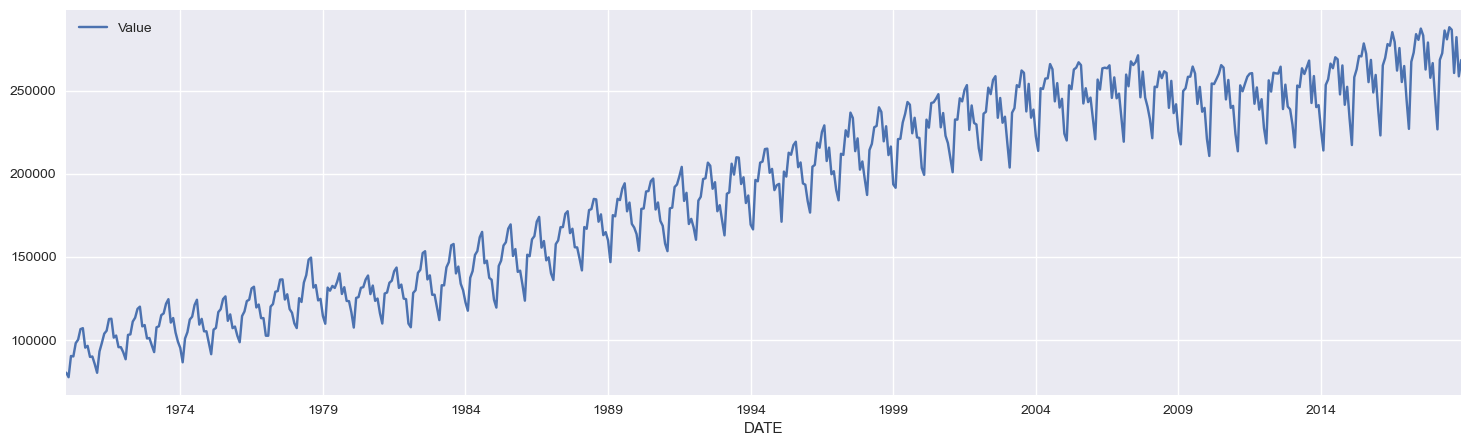

In [10]:
# CODE HERE
df.plot(figsize=(18,5))
plt.show()

**TASK: Perform a Seasonal Decomposition on the model and plot out the ETS components**

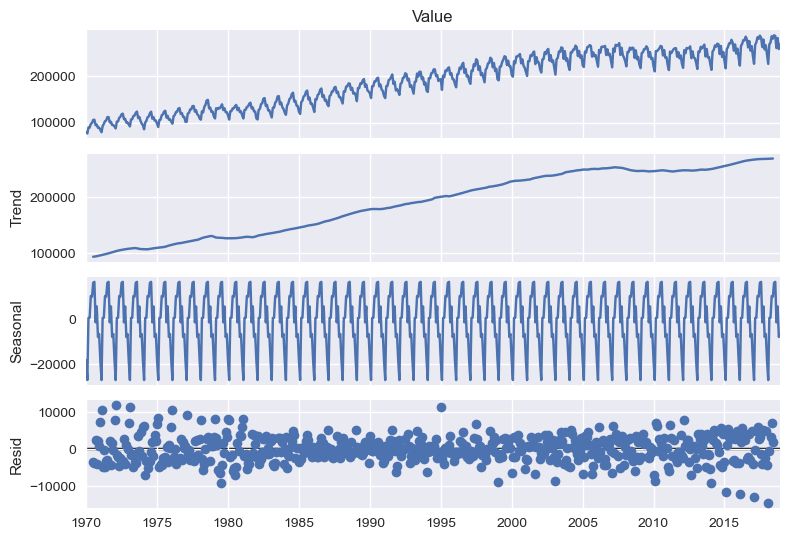

In [11]:
# CODE HERE
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df["Value"] , model="additive")
result.plot()
plt.show()

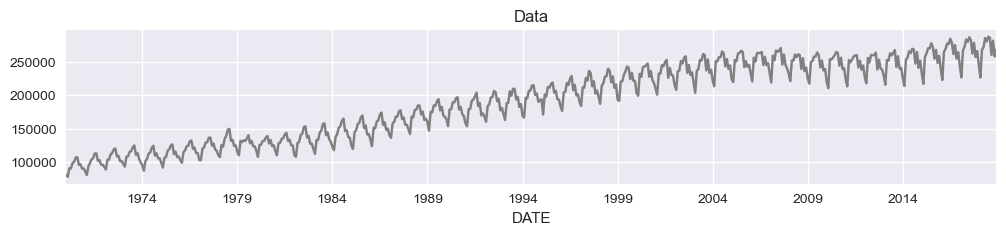

In [12]:
result.observed.plot(figsize=(12,2), title = "Data", c="gray")
plt.show()

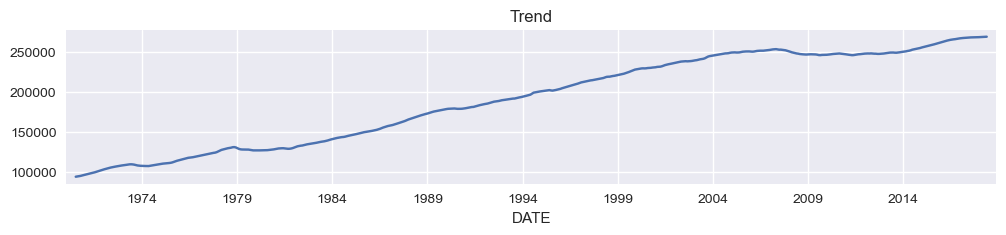

In [13]:
result.trend.plot(figsize=(12,2) , title = "Trend")
plt.show()

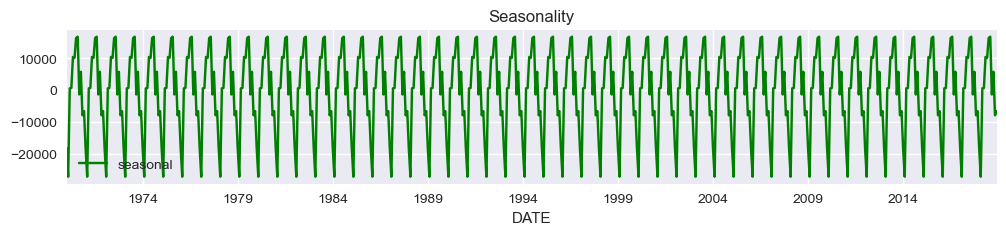

In [14]:
result.seasonal.plot(figsize=(12,2) , title = "Seasonality", legend = True, color = "green")
plt.show()

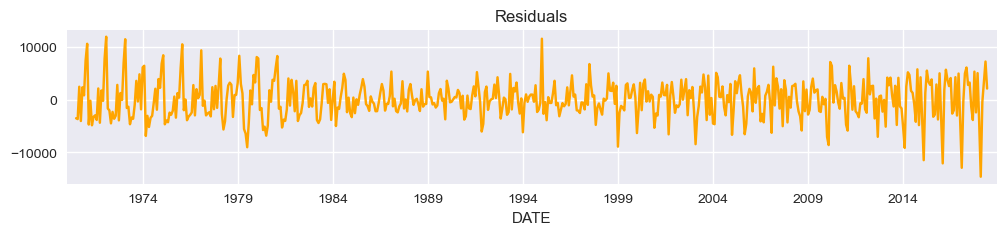

In [15]:
result.resid.plot(figsize=(12,2), title ="Residuals", c="orange")
plt.show()

In [16]:
result.nobs

(588,)

## Train Test Split

**TASK: Figure out the length of the data set**

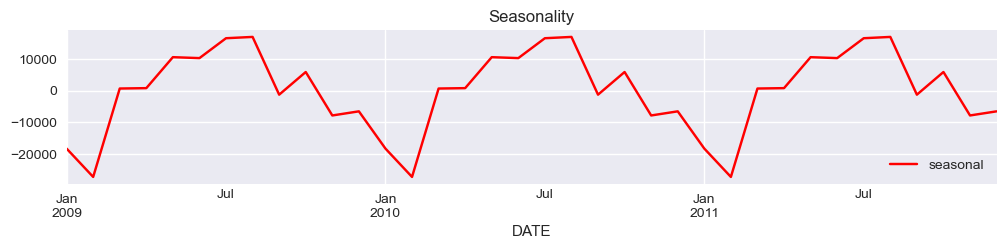

In [17]:
result.seasonal.loc["2009":"2011"].plot(figsize=(12,2) , title = "Seasonality", legend = True, c="r")
plt.show()

In [ ]:
# CODE HERE

In [18]:
len(df)

588

In [19]:
train_len = len(df) - 12 # seasonality is 12 month
train_len

576

**TASK: Split the data into a train/test split where the test set is the last 12 months of data.**

In [20]:
# CODE HERE
train = df.iloc[:train_len]
test = df.iloc[train_len:]

In [21]:
len(test)

12

## Scale Data

**TASK: Use a MinMaxScaler to scale the train and test sets into scaled versions.**

In [23]:
# CODE HERE
from sklearn.preprocessing import MinMaxScaler

In [24]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train)
scaled_test = scaler.transform(test)

# Time Series Generator

**TASK: Create a TimeSeriesGenerator object based off the scaled_train data. The n_input is up to you, but at a minimum it should be at least 12.**

In [ ]:
#CODE HERE
import keras

In [25]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [26]:
n_input = 12
n_features = 1

In [37]:
trained_generator = TimeseriesGenerator(scaled_train ,
                                        scaled_train , 
                                        length= n_input , 
                                        batch_size=1)

In [39]:
X,y = trained_generator[0]
X,y

(array([[[0.0130109 ],
         [0.        ],
         [0.06089061],
         [0.05961858],
         [0.09780801],
         [0.10763646],
         [0.13792216],
         [0.14067108],
         [0.08485905],
         [0.08992334],
         [0.05832273],
         [0.0594042 ]]]),
 array([[0.03760821]]))

In [40]:
X.shape , y.shape

((1, 12, 1), (1, 1))

### Create the Model

**TASK: Create a Keras Sequential Model with as many LSTAM units you want and a final Dense Layer.**

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , LSTM

In [42]:
model = Sequential()

model.add(LSTM(units=150 , activation='relu', input_shape = (n_input , n_features)))
model.add(Dense(units = 1))
model.compile(optimizer = 'adam', loss = 'mse')

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150)            │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,351 (356.84 KB)

 Trainable params: 91,351 (356.84 KB)

 Non-trainable params: 0 (0.00 B)

**TASK: Fit the model to the generator (it should be a lot of epochs, but do as many as you have the patience for! :)**

In [44]:
# CODE HERE
model.fit(trained_generator , epochs=50)

Epoch 1/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0121
Epoch 2/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0057
Epoch 3/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0051
Epoch 4/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0031
Epoch 5/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022
Epoch 6/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0019
Epoch 7/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0017
Epoch 8/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0015
Epoch 9/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013
Epoch 10/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0010
Epoch 11/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0011
Epoch 12/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.6056e-04
Epoch 13/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.9110e-04
Epoch 14/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 9.0470e-04
Epoch 15/50
564/564 ━━━━━━━━━━━━━━━━━━━━ 2s 3

**TASK: Plot the history of the loss that occured during training.**

In [46]:
# CODE HERE
loss = pd.DataFrame(model.history.history)
loss

,loss
0,0.012123
1,0.005748
2,0.005059
3,0.003138
4,0.002246
5,0.001882
6,0.001724
7,0.001523
8,0.001326
9,0.001048


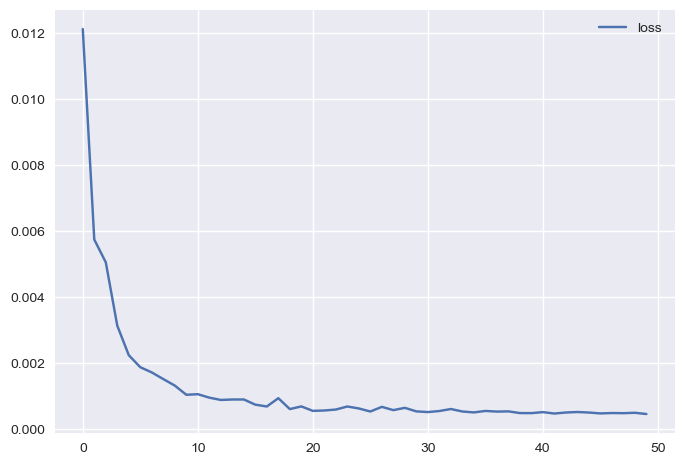

In [47]:
loss.plot();

## Evaluate on Test Data

**TASK: Based on your test data and input size, create an appropriate;y sized "first evaluation batch" like we did in the lecture.**

In [57]:
# CODE HERE
first_eval_batch = scaled_train[- n_input:]
first_eval_batch

array([[0.79630397],
       [0.71226435],
       [0.90477416],
       [0.93121043],
       [0.98386382],
       [0.96757519],
       [1.        ],
       [0.9801859 ],
       [0.8824684 ],
       [0.95995255],
       [0.85883345],
       [0.90086755]])

**TASK: Generate predictions into the same time stamps as the test set**

In [49]:
# CODE HERE
n_features , n_input

(1, 12)

In [58]:
first_eval_batch = scaled_train[- n_input:]
first_eval_batch = first_eval_batch.reshape(1,n_input , n_features)
# see X.shape = (1 , n_input , n_features)
first_eval_batch

array([[[0.79630397],
        [0.71226435],
        [0.90477416],
        [0.93121043],
        [0.98386382],
        [0.96757519],
        [1.        ],
        [0.9801859 ],
        [0.8824684 ],
        [0.95995255],
        [0.85883345],
        [0.90086755]]])

In [59]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([[0.8110479]], dtype=float32)

In [60]:
model.predict(first_eval_batch)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([0.8110479], dtype=float32)

In [61]:
test_predictions = []

first_eval_batch = scaled_train[- n_input:]
current_batch = first_eval_batch.reshape(1,n_input , n_features)
# see X.shape = (1 , n_input , n_features)


for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)

    current_batch = np.append(current_batch[:,1:,:] , [[current_pred]], axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [62]:
my_first_pred = model.predict(current_batch)
my_first_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.8254826]], dtype=float32)

## Inverse Transformations and Compare

**TASK: Inverse Transform your new forecasted predictions.**

In [63]:
#CODE HERE
current_batch

array([[[0.81104791],
        [0.73765337],
        [0.90987462],
        [0.9432525 ],
        [1.00015008],
        [0.98374587],
        [1.01789343],
        [0.99331802],
        [0.90263671],
        [0.96971726],
        [0.87501544],
        [0.9133876 ]]])

In [65]:
test_predictions

[array([0.8110479], dtype=float32),
 array([0.7376534], dtype=float32),
 array([0.9098746], dtype=float32),
 array([0.9432525], dtype=float32),
 array([1.0001501], dtype=float32),
 array([0.9837459], dtype=float32),
 array([1.0178934], dtype=float32),
 array([0.993318], dtype=float32),
 array([0.9026367], dtype=float32),
 array([0.96971726], dtype=float32),
 array([0.87501544], dtype=float32),
 array([0.9133876], dtype=float32)]

In [66]:
true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[247681.76770198],
       [232276.18099701],
       [268425.59220403],
       [275431.64381522],
       [287374.5028857 ],
       [283931.2424832 ],
       [291098.84959996],
       [285940.44598836],
       [266906.34740013],
       [280986.62346768],
       [261108.61536831],
       [269162.96991545]])

**TASK: Create a new dataframe that has both the original test values and your predictions for them.**

In [67]:
# CODE HERE
test["Predictions"] = true_predictions
test

,Value,Predictions
DATE,,
2018-01-01,245695.0,247681.767702
2018-02-01,226660.0,232276.180997
2018-03-01,268480.0,268425.592204
2018-04-01,272475.0,275431.643815
2018-05-01,286164.0,287374.502886
2018-06-01,280877.0,283931.242483
2018-07-01,288145.0,291098.849600
2018-08-01,286608.0,285940.445988
2018-09-01,260595.0,266906.347400


**TASK: Plot out the test set against your own predicted values.**

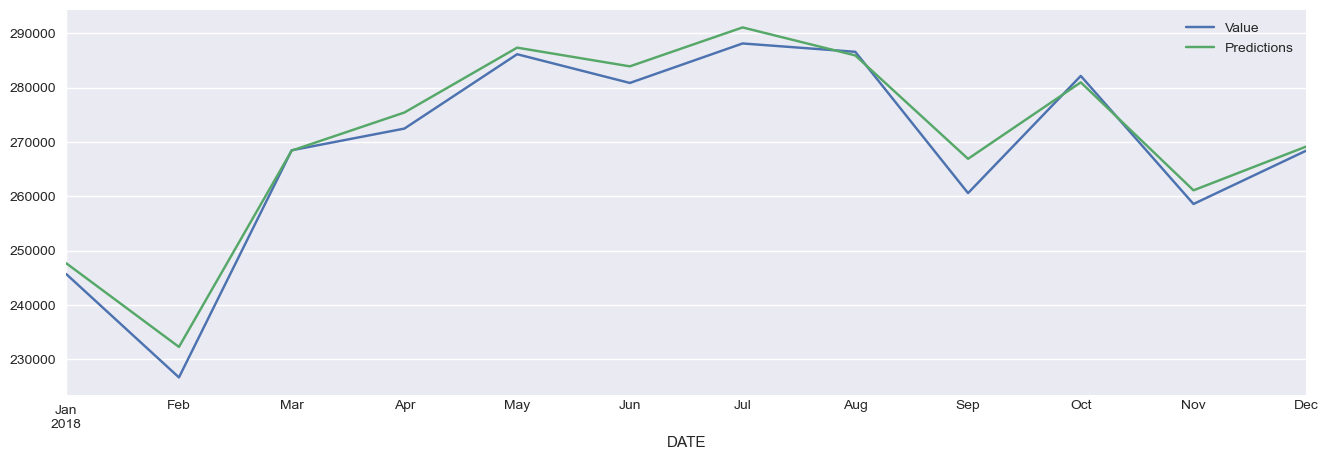

In [70]:
# CODE HERE
test.plot(figsize = (16,5))
plt.show()

# Saving Models

**TASK: Optional, Save your model!**

In [71]:
model.save('my_rnn_model.h5')

In [72]:
from tensorflow.keras.models import load_model

In [73]:
new_model = load_model('my_rnn_model.h5', compile=False)
new_model.compile(optimizer = 'adam', loss = 'mean_squared_error')
new_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 150)            │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           151 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,351 (356.84 KB)

 Trainable params: 91,351 (356.84 KB)

 Non-trainable params: 0 (0.00 B)